In [1]:
import numpy as np
import pandas as pd
import time

In [3]:
import os
os.getcwd()

'C:\\Users\\pmgho'

In [4]:
os.chdir('C:\\Users\\pmgho\\OneDrive\\Documents\\ML Capstone Project')

In [5]:
os.getcwd()

'C:\\Users\\pmgho\\OneDrive\\Documents\\ML Capstone Project'

In [6]:
df = pd.read_csv('Social_Network_Ads.csv')
df

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0
...,...,...,...,...,...
395,15691863,Female,46,41000,1
396,15706071,Male,51,23000,1
397,15654296,Female,50,20000,1
398,15755018,Male,36,33000,0


In [7]:
df = df[['Age','EstimatedSalary','Purchased']]

In [8]:
df.head()

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


In [9]:
X = df.iloc[:,0:2]
y = df.iloc[:,-1]

In [10]:
X

,Age,EstimatedSalary
0,19,19000
1,35,20000
2,26,43000
3,27,57000
4,19,76000
...,...,...
395,46,41000
396,51,23000
397,50,20000
398,36,33000


In [11]:
y

0      0
1      0
2      0
3      0
4      0
      ..
395    1
396    1
397    1
398    0
399    1
Name: Purchased, Length: 400, dtype: int64

In [12]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [13]:
X_scaled.shape

(400, 2)

In [14]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [15]:
X_train.shape

(320, 2)

In [16]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense

In [17]:
model = Sequential()

model.add(Dense(10,activation='relu',input_dim=2))
model.add(Dense(10,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

C:\Users\pmgho\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [18]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 10)                  │              30 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │             110 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              11 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 151 (604.00 B)

 Trainable params: 151 (604.00 B)

 Non-trainable params: 0 (0.00 B)

In [19]:
model.compile(loss='binary_crossentropy',metrics=['accuracy'])
history = model.fit(X_scaled,y,epochs=500,batch_size=1,validation_split=0.2)

Epoch 1/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8219 - loss: 0.4819 - val_accuracy: 0.8625 - val_loss: 0.5532
Epoch 2/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8656 - loss: 0.3373 - val_accuracy: 0.9125 - val_loss: 0.4411
Epoch 3/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8719 - loss: 0.2851 - val_accuracy: 0.9250 - val_loss: 0.3629
Epoch 4/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8844 - loss: 0.2715 - val_accuracy: 0.9375 - val_loss: 0.3063
Epoch 5/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8750 - loss: 0.2705 - val_accuracy: 0.9750 - val_loss: 0.2628
Epoch 6/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8906 - loss: 0.2681 - val_accuracy: 0.9750 - val_loss: 0.2418
Epoch 7/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8813 - loss: 0.2686 - val_accuracy: 0.9750 - val_loss: 0.2238
Epoch 8/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8844 - loss: 0.2654 - val_accu

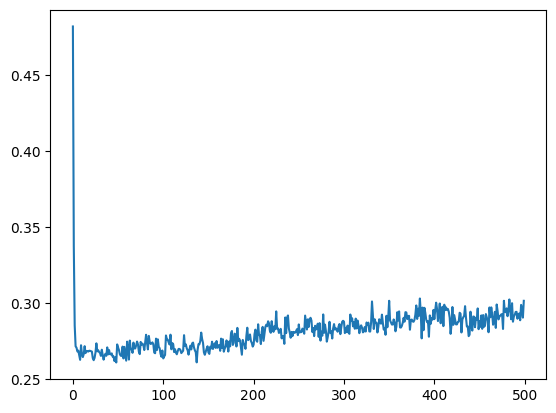

In [20]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'])

In [21]:
model = Sequential()

model.add(Dense(10,activation='relu',input_dim=2))
model.add(Dense(10,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

In [22]:
model.compile(loss='binary_crossentropy',metrics=['accuracy'])
#start = time.time()
history = model.fit(X_scaled,y,epochs=10,batch_size=250,validation_split=0.2)
#print(time.time() - start)

Epoch 1/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 303ms/step - accuracy: 0.5781 - loss: 0.7034 - val_accuracy: 0.5250 - val_loss: 0.6891
Epoch 2/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.6125 - loss: 0.6906 - val_accuracy: 0.5625 - val_loss: 0.6901
Epoch 3/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.6469 - loss: 0.6814 - val_accuracy: 0.5750 - val_loss: 0.6875
Epoch 4/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.6719 - loss: 0.6742 - val_accuracy: 0.6000 - val_loss: 0.6899
Epoch 5/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.6875 - loss: 0.6676 - val_accuracy: 0.6250 - val_loss: 0.6896
Epoch 6/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.7000 - loss: 0.6617 - val_accuracy: 0.6375 - val_loss: 0.6893
Epoch 7/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.7188 - loss: 0.6564 - val_accuracy: 0.6625 - val_loss: 0.6882
Epoch 8/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.7281 - loss: 0.6512 - val_accuracy: 0.6750 - val_loss: 0.6857

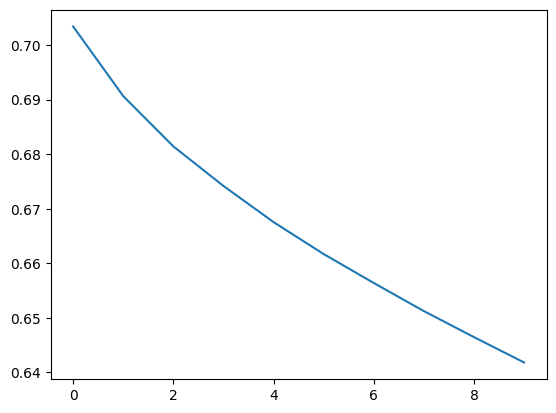

In [23]:
plt.plot(history.history['loss'])

In [25]:
model.compile(loss='binary_crossentropy',metrics=['accuracy'])
start = time.time()
history = model.fit(X_scaled,y,epochs=10,batch_size=250,validation_split=0.2)
print('-------------------*********************---------------------')
print('Time:')
print(time.time() - start)

Epoch 1/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 272ms/step - accuracy: 0.7375 - loss: 0.5813 - val_accuracy: 0.6875 - val_loss: 0.6578
Epoch 2/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.7500 - loss: 0.5718 - val_accuracy: 0.7125 - val_loss: 0.6540
Epoch 3/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.7500 - loss: 0.5652 - val_accuracy: 0.7250 - val_loss: 0.6480
Epoch 4/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.7656 - loss: 0.5598 - val_accuracy: 0.7250 - val_loss: 0.6439
Epoch 5/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.7719 - loss: 0.5549 - val_accuracy: 0.7250 - val_loss: 0.6416
Epoch 6/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.7750 - loss: 0.5504 - val_accuracy: 0.7250 - val_loss: 0.6382
Epoch 7/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.7750 - loss: 0.5464 - val_accuracy: 0.7250 - val_loss: 0.6345
Epoch 8/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.7750 - loss: 0.5424 - val_accuracy: 0.7250 - val_loss: 0.6336